In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

import torchvision.transforms as transforms
import torchvision.models as models

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

In [3]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Using device: {DEVICE}")

✅ Using device: cuda


In [5]:
import zipfile
import os

# ── Unzip the file ──────────────────────────────────────────
zip_path    = "/content/sampled_images.zip"   # ← update this to your zip filename
extract_dir = "/content/dataset"              # folder where it will be extracted

os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print("✅ Unzipped successfully!")
print("📁 Contents:", os.listdir(extract_dir))

✅ Unzipped successfully!
📁 Contents: ['sampled_images']


In [6]:
CSV_PATH   = "/content/data.csv"
IMG_DIR    = "/content/dataset/sampled_images"

# **Task -1 Data Preparation**

In [7]:
df = pd.read_csv(CSV_PATH)
print(f"\n📄 Loaded CSV: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"   Columns available: {list(df.columns)}")


📄 Loaded CSV: 6000 rows, 9 columns
   Columns available: ['Filename', 'AQI', 'PM2.5', 'PM10', 'O3', 'CO', 'SO2', 'NO2', 'AQI_Class']


In [8]:
df = df[['Filename', 'AQI_Class']].dropna()
print(f"   After selecting required columns: {df.shape[0]} samples")

   After selecting required columns: 6000 samples


In [9]:
print("\n📊 AQI Class Distribution:")
print(df["AQI_Class"].value_counts())


📊 AQI Class Distribution:
AQI_Class
a_Good                              1000
b_Moderate                          1000
c_Unhealthy_for_Sensitive_Groups    1000
d_Unhealthy                         1000
e_Very_Unhealthy                    1000
f_Severe                            1000
Name: count, dtype: int64


In [10]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["label"] = le.fit_transform(df["AQI_Class"])

NUM_CLASSES = len(le.classes_)
CLASS_NAMES  = list(le.classes_)
print(f"\n🏷️  Classes ({NUM_CLASSES} total): {CLASS_NAMES}")
print(f"   Label mapping: { {cls: i for i, cls in enumerate(CLASS_NAMES)} }")


🏷️  Classes (6 total): ['a_Good', 'b_Moderate', 'c_Unhealthy_for_Sensitive_Groups', 'd_Unhealthy', 'e_Very_Unhealthy', 'f_Severe']
   Label mapping: {'a_Good': 0, 'b_Moderate': 1, 'c_Unhealthy_for_Sensitive_Groups': 2, 'd_Unhealthy': 3, 'e_Very_Unhealthy': 4, 'f_Severe': 5}


In [11]:
IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),       # Resize to 224×224
    transforms.RandomHorizontalFlip(),             # Data augmentation: flip image
    transforms.RandomRotation(10),                 # Data augmentation: slight rotation
    transforms.ColorJitter(brightness=0.2,         # Data augmentation: vary colors
                           contrast=0.2),
    transforms.ToTensor(),                         # Convert PIL image → PyTorch tensor
    transforms.Normalize(                          # Normalize using ImageNet statistics
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

# Validation/Test transform: NO augmentation, just resize and normalize
val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])


In [12]:
class AQIDataset(Dataset):
    """Custom Dataset for loading AQI images and labels."""

    def __init__(self, dataframe, img_root, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.img_root  = img_root
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # Get image path and label for this sample
        row       = self.df.iloc[idx]
        img_path  = os.path.join(self.img_root, row["image_path"])
        label     = int(row["label"])

        # Open image; handle missing files gracefully
        try:
            image = Image.open(img_path).convert("RGB")
        except FileNotFoundError:
            # Return a blank image if file is missing
            image = Image.new("RGB", (IMG_SIZE, IMG_SIZE), color=(128, 128, 128))

        if self.transform:
            image = self.transform(image)

        return image, label

In [13]:
total      = len(df)
train_size = int(0.70 * total)
val_size   = int(0.15 * total)
test_size  = total - train_size - val_size  # Remainder goes to test

# Shuffle the DataFrame before splitting
df_shuffled = df.sample(frac=1, random_state=SEED).reset_index(drop=True)

train_df = df_shuffled[:train_size]
val_df   = df_shuffled[train_size : train_size + val_size]
test_df  = df_shuffled[train_size + val_size :]

# Rename 'Filename' column to 'image_path' for the dataset
train_df = train_df.rename(columns={'Filename': 'image_path'})
val_df   = val_df.rename(columns={'Filename': 'image_path'})
test_df  = test_df.rename(columns={'Filename': 'image_path'})

print(f"\n✂️  Data Split:")
print(f"   Train : {len(train_df)} samples ({len(train_df)/total*100:.1f}%)")
print(f"   Val   : {len(val_df)} samples ({len(val_df)/total*100:.1f}%) ")
print(f"   Test  : {len(test_df)} samples ({len(test_df)/total*100:.1f}%)")

# Create Dataset objects
train_dataset = AQIDataset(train_df, IMG_DIR, transform=train_transform)
val_dataset   = AQIDataset(val_df,   IMG_DIR, transform=val_test_transform)
test_dataset  = AQIDataset(test_df,  IMG_DIR, transform=val_test_transform)

# Create DataLoaders (batch generators)
BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"\n📦 Batch size: {BATCH_SIZE}")
print(f"   Train batches: {len(train_loader)}")
print(f"   Val batches  : {len(val_loader)}")
print(f"   Test batches : {len(test_loader)}")


✂️  Data Split:
   Train : 4200 samples (70.0%)
   Val   : 900 samples (15.0%) 
   Test  : 900 samples (15.0%)

📦 Batch size: 32
   Train batches: 132
   Val batches  : 29
   Test batches : 29


# **Task-2 BASIC CNN MODEL (Trained from scratch)**

In [14]:
cnn_model = nn.Sequential(
    # Block 1
    nn.Conv2d(3, 32, kernel_size=3, padding=1),    # [B, 3, 224, 224] → [B, 32, 224, 224]
    nn.BatchNorm2d(32),
    nn.ReLU(inplace=True),
    nn.MaxPool2d(2, 2),                            # → [B, 32, 112, 112]

    # Block 2
    nn.Conv2d(32, 64, kernel_size=3, padding=1),   # → [B, 64, 112, 112]
    nn.BatchNorm2d(64),
    nn.ReLU(inplace=True),
    nn.MaxPool2d(2, 2),                            # → [B, 64, 56, 56]

    # Block 3
    nn.Conv2d(64, 128, kernel_size=3, padding=1),  # → [B, 128, 56, 56]
    nn.BatchNorm2d(128),
    nn.ReLU(inplace=True),
    nn.MaxPool2d(2, 2),                            # → [B, 128, 28, 28]

    # Block 4
    nn.Conv2d(128, 256, kernel_size=3, padding=1), # → [B, 256, 28, 28]
    nn.BatchNorm2d(256),
    nn.ReLU(inplace=True),
    nn.AdaptiveAvgPool2d((4, 4)),                  # → [B, 256, 4, 4]

    # Classifier
    nn.Flatten(),                                  # → [B, 4096]
    nn.Linear(256 * 4 * 4, 512),
    nn.ReLU(inplace=True),
    nn.Dropout(0.5),
    nn.Linear(512, NUM_CLASSES),                   # → [B, NUM_CLASSES]
).to(DEVICE)

# Count parameters
total_params = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)
print(f"🧠 BasicCNN created.")
print(f"   Trainable parameters: {total_params:,}")
print(f"\nModel Architecture:\n{cnn_model}")

🧠 BasicCNN created.
   Trainable parameters: 2,490,118

Model Architecture:
Sequential(
  (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): ReLU(inplace=True)
  (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (10): ReLU(inplace=True)
  (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): BatchNorm2d(256, eps=

# **Task 3 - Pretrained CNN Model (Transfer Learning)**

In [15]:
pretrained_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
in_features = pretrained_model.fc.in_features
pretrained_model.fc = nn.Linear(in_features, NUM_CLASSES)

# Names of first 10 conv layers
FREEZE_CONV_LAYERS = [
    "conv1",
    "layer1.0.conv1", "layer1.0.conv2",
    "layer1.1.conv1", "layer1.1.conv2",
    "layer2.0.conv1", "layer2.0.conv2",
    "layer2.0.downsample.0",   # this is also a conv layer
    "layer2.1.conv1", "layer2.1.conv2",
]

for name, module in pretrained_model.named_modules():
    if name in FREEZE_CONV_LAYERS:
        for param in module.parameters():
            param.requires_grad = False   # ❄️ freeze this conv + its params

pretrained_model = pretrained_model.to(DEVICE)

# ── Verify ──────────────────────────────────────────────────
print(f"{'Layer':<35} {'Type':<12} {'Status'}")
print("-" * 60)
for name, module in pretrained_model.named_modules():
    if isinstance(module, (nn.Conv2d, nn.Linear)):
        frozen = not next(module.parameters()).requires_grad
        status = "❄️  FROZEN" if frozen else "🔥 trainable"
        layer_type = "Conv2d" if isinstance(module, nn.Conv2d) else "Linear(fc)"
        print(f"{name:<35} {layer_type:<12} {status}")

# ── Count ───────────────────────────────────────────────────
frozen_count    = sum(1 for p in pretrained_model.parameters() if not p.requires_grad)
trainable_count = sum(p.numel() for p in pretrained_model.parameters() if p.requires_grad)
print(f"\n❄️  Frozen parameter tensors : {frozen_count}")
print(f"🔥 Trainable parameters     : {trainable_count:,}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 206MB/s]


Layer                               Type         Status
------------------------------------------------------------
conv1                               Conv2d       ❄️  FROZEN
layer1.0.conv1                      Conv2d       ❄️  FROZEN
layer1.0.conv2                      Conv2d       ❄️  FROZEN
layer1.1.conv1                      Conv2d       ❄️  FROZEN
layer1.1.conv2                      Conv2d       ❄️  FROZEN
layer2.0.conv1                      Conv2d       ❄️  FROZEN
layer2.0.conv2                      Conv2d       ❄️  FROZEN
layer2.0.downsample.0               Conv2d       ❄️  FROZEN
layer2.1.conv1                      Conv2d       ❄️  FROZEN
layer2.1.conv2                      Conv2d       ❄️  FROZEN
layer3.0.conv1                      Conv2d       🔥 trainable
layer3.0.conv2                      Conv2d       🔥 trainable
layer3.0.downsample.0               Conv2d       🔥 trainable
layer3.1.conv1                      Conv2d       🔥 trainable
layer3.1.conv2                      Con

# **Task 4 - Model Training and Evaluation**

In [16]:
def train_one_epoch(model, loader, optimizer, criterion):
    """
    Trains the model for one epoch.
    Returns: average loss, accuracy over training set
    """
    model.train()           # Set model to training mode (enables Dropout, BatchNorm updates)
    running_loss   = 0.0
    correct        = 0
    total          = 0

    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()           # Clear previous gradients
        outputs = model(images)         # Forward pass: get predictions
        loss    = criterion(outputs, labels)  # Compute loss
        loss.backward()                 # Backward pass: compute gradients
        optimizer.step()                # Update model weights

        running_loss += loss.item() * images.size(0)
        preds    = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc  = correct / total
    return epoch_loss, epoch_acc


def evaluate_model(model, loader, criterion):
    """
    Evaluates the model on a DataLoader (val or test set).
    Returns: average loss, accuracy, all predictions, all true labels
    """
    model.eval()            # Evaluation mode: disables Dropout, freezes BatchNorm
    running_loss = 0.0
    all_preds    = []
    all_labels   = []

    with torch.no_grad():   # No gradients needed during evaluation → saves memory
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss    = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds         = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = running_loss / len(loader.dataset)
    accuracy = accuracy_score(all_labels, all_preds)
    return avg_loss, accuracy, all_preds, all_labels

In [20]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

def print_metrics(y_true, y_pred, model_name="Model"):
    """Prints Accuracy, Precision, Recall, F1 and full classification report."""
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    rec  = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1   = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    print(f"\n📊 {model_name} — Test Set Metrics:")
    print(f"   Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
    print(f"   Precision : {prec:.4f}")
    print(f"   Recall    : {rec:.4f}")
    print(f"   F1-Score  : {f1:.4f}")
    print(f"\n   Full Classification Report:")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0))
    return {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1}


def plot_confusion_matrix(y_true, y_pred, class_names, title="Confusion Matrix"):
    """Plots a heatmap confusion matrix."""
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(max(8, len(class_names)), max(6, len(class_names)-1)))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_xlabel("Predicted Label", fontsize=12)
    ax.set_ylabel("True Label", fontsize=12)
    ax.set_title(title, fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"confusion_matrix_{title.replace(' ', '_')}.png", dpi=150)
    plt.show()
    print(f"   Saved: confusion_matrix_{title.replace(' ', '_')}.png")

In [18]:
def train_model(model, train_loader, val_loader, num_epochs=5, lr=1e-3, model_name="model"):
    """
    Full training loop.
    Returns history dict with train/val loss and accuracy per epoch.
    """
    criterion = nn.CrossEntropyLoss()   # Standard loss for multi-class classification
    optimizer = optim.Adam(model.parameters(), lr=lr)  # Adam adapts learning rate automatically
    # LR scheduler: reduce LR by factor 0.5 if val loss doesn't improve for 3 epochs
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min",
                                                      factor=0.5, patience=3)

    history = {"train_loss": [], "val_loss": [],
               "train_acc":  [], "val_acc":  []}
    best_val_loss = float("inf")

    print(f"\n🚀 Training {model_name} for {num_epochs} epochs...")
    print(f"   Optimizer: Adam  |  LR: {lr}  |  Loss: CrossEntropyLoss")
    print("-" * 55)

    for epoch in range(1, num_epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        val_loss, val_acc, _, _ = evaluate_model(model, val_loader, criterion)

        scheduler.step(val_loss)   # Adjust learning rate based on val loss

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        # Save best model weights
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), f"best_{model_name}.pth")
            marker = " ✅ (saved)"
        else:
            marker = ""

        print(f"   Epoch {num_epochs} | "
                  f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
                  f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}{marker}")

    # Load best weights before returning
    model.load_state_dict(torch.load(f"best_{model_name}.pth"))
    print(f"\n   Best val loss: {best_val_loss:.4f} — loaded best weights.")
    return history

In [21]:
NUM_EPOCHS = 5   # Increase to 30–50 for better results if time permits

# --- Train Basic CNN ---
print("\n" + "="*60)
print("TRAINING BASIC CNN FROM SCRATCH")
print("="*60)
cnn_history = train_model(
    cnn_model, train_loader, val_loader,
    num_epochs=NUM_EPOCHS, lr=1e-3,
    model_name="basic_cnn"
)

# --- Train Pretrained ResNet18 ---
print("\n" + "="*60)
print("TRAINING PRETRAINED RESNET18 (Transfer Learning)")
print("="*60)
pretrain_history = train_model(
    pretrained_model, train_loader, val_loader,
    num_epochs=NUM_EPOCHS, lr=1e-4,    # Lower LR for pretrained model
    model_name="resnet18_pretrained"
)



TRAINING BASIC CNN FROM SCRATCH

🚀 Training basic_cnn for 5 epochs...
   Optimizer: Adam  |  LR: 0.001  |  Loss: CrossEntropyLoss
-------------------------------------------------------
   Epoch 5 | Train Loss: 1.1217, Acc: 0.5526 | Val Loss: 0.9018, Acc: 0.6189 ✅ (saved)
   Epoch 5 | Train Loss: 0.9840, Acc: 0.5938 | Val Loss: 0.8522, Acc: 0.6600 ✅ (saved)
   Epoch 5 | Train Loss: 0.8938, Acc: 0.6302 | Val Loss: 0.6704, Acc: 0.7178 ✅ (saved)
   Epoch 5 | Train Loss: 0.8291, Acc: 0.6626 | Val Loss: 0.7743, Acc: 0.6700
   Epoch 5 | Train Loss: 0.8150, Acc: 0.6640 | Val Loss: 0.6568, Acc: 0.7267 ✅ (saved)

   Best val loss: 0.6568 — loaded best weights.

TRAINING PRETRAINED RESNET18 (Transfer Learning)

🚀 Training resnet18_pretrained for 5 epochs...
   Optimizer: Adam  |  LR: 0.0001  |  Loss: CrossEntropyLoss
-------------------------------------------------------
   Epoch 5 | Train Loss: 0.7419, Acc: 0.7283 | Val Loss: 0.3102, Acc: 0.9067 ✅ (saved)
   Epoch 5 | Train Loss: 0.2682, Acc:


📊 BasicCNN — Test Set Metrics:
   Accuracy  : 0.7122  (71.22%)
   Precision : 0.7236
   Recall    : 0.7122
   F1-Score  : 0.7015

   Full Classification Report:
                                  precision    recall  f1-score   support

                          a_Good       0.61      0.82      0.70       134
                      b_Moderate       0.76      0.62      0.69       146
c_Unhealthy_for_Sensitive_Groups       0.69      0.35      0.46       150
                     d_Unhealthy       0.60      0.80      0.69       152
                e_Very_Unhealthy       0.83      0.75      0.79       154
                        f_Severe       0.82      0.91      0.87       164

                        accuracy                           0.71       900
                       macro avg       0.72      0.71      0.70       900
                    weighted avg       0.72      0.71      0.70       900



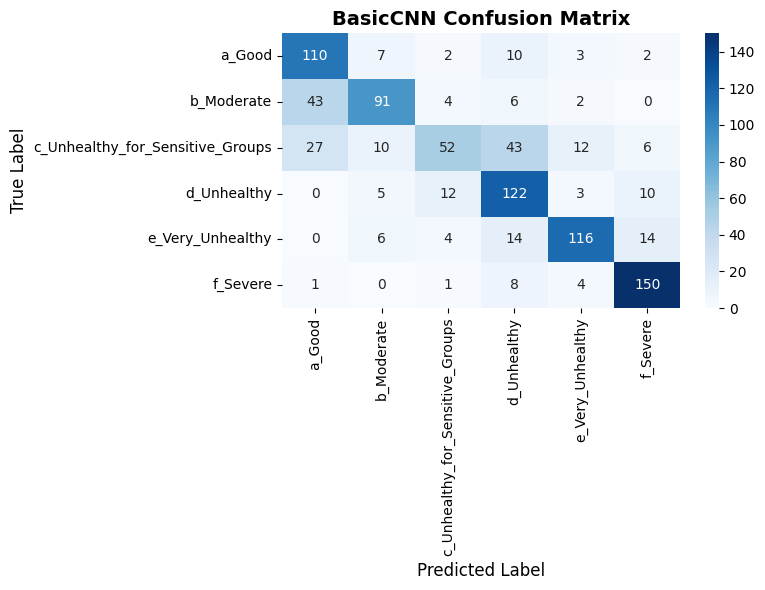

   Saved: confusion_matrix_BasicCNN_Confusion_Matrix.png

📊 ResNet18 (Pretrained) — Test Set Metrics:
   Accuracy  : 0.9578  (95.78%)
   Precision : 0.9581
   Recall    : 0.9578
   F1-Score  : 0.9576

   Full Classification Report:
                                  precision    recall  f1-score   support

                          a_Good       0.96      0.99      0.97       134
                      b_Moderate       0.96      0.96      0.96       146
c_Unhealthy_for_Sensitive_Groups       0.92      0.88      0.90       150
                     d_Unhealthy       0.93      0.99      0.96       152
                e_Very_Unhealthy       0.97      0.94      0.96       154
                        f_Severe       1.00      0.99      0.99       164

                        accuracy                           0.96       900
                       macro avg       0.96      0.96      0.96       900
                    weighted avg       0.96      0.96      0.96       900



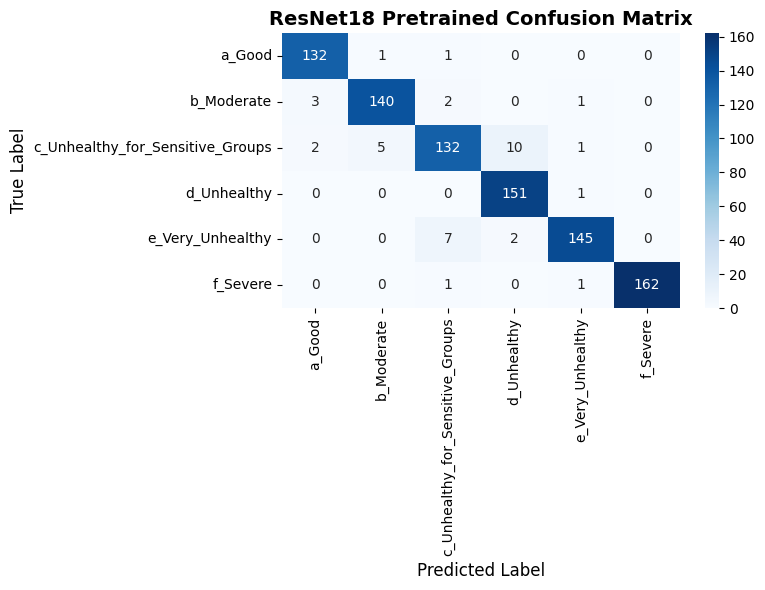

   Saved: confusion_matrix_ResNet18_Pretrained_Confusion_Matrix.png


In [27]:
criterion = nn.CrossEntropyLoss()

# Evaluate BasicCNN
_, _, cnn_preds, cnn_labels = evaluate_model(cnn_model, test_loader, criterion)
cnn_metrics = print_metrics(cnn_labels, cnn_preds, "BasicCNN")
plot_confusion_matrix(cnn_labels, cnn_preds, CLASS_NAMES, "BasicCNN Confusion Matrix")  # ← here

# Evaluate ResNet18
_, _, pt_preds, pt_labels = evaluate_model(pretrained_model, test_loader, criterion)
pt_metrics = print_metrics(pt_labels, pt_preds, "ResNet18 (Pretrained)")
plot_confusion_matrix(pt_labels, pt_preds, CLASS_NAMES, "ResNet18 Pretrained Confusion Matrix")  # ← here

# **Task 5 - Training Curves**

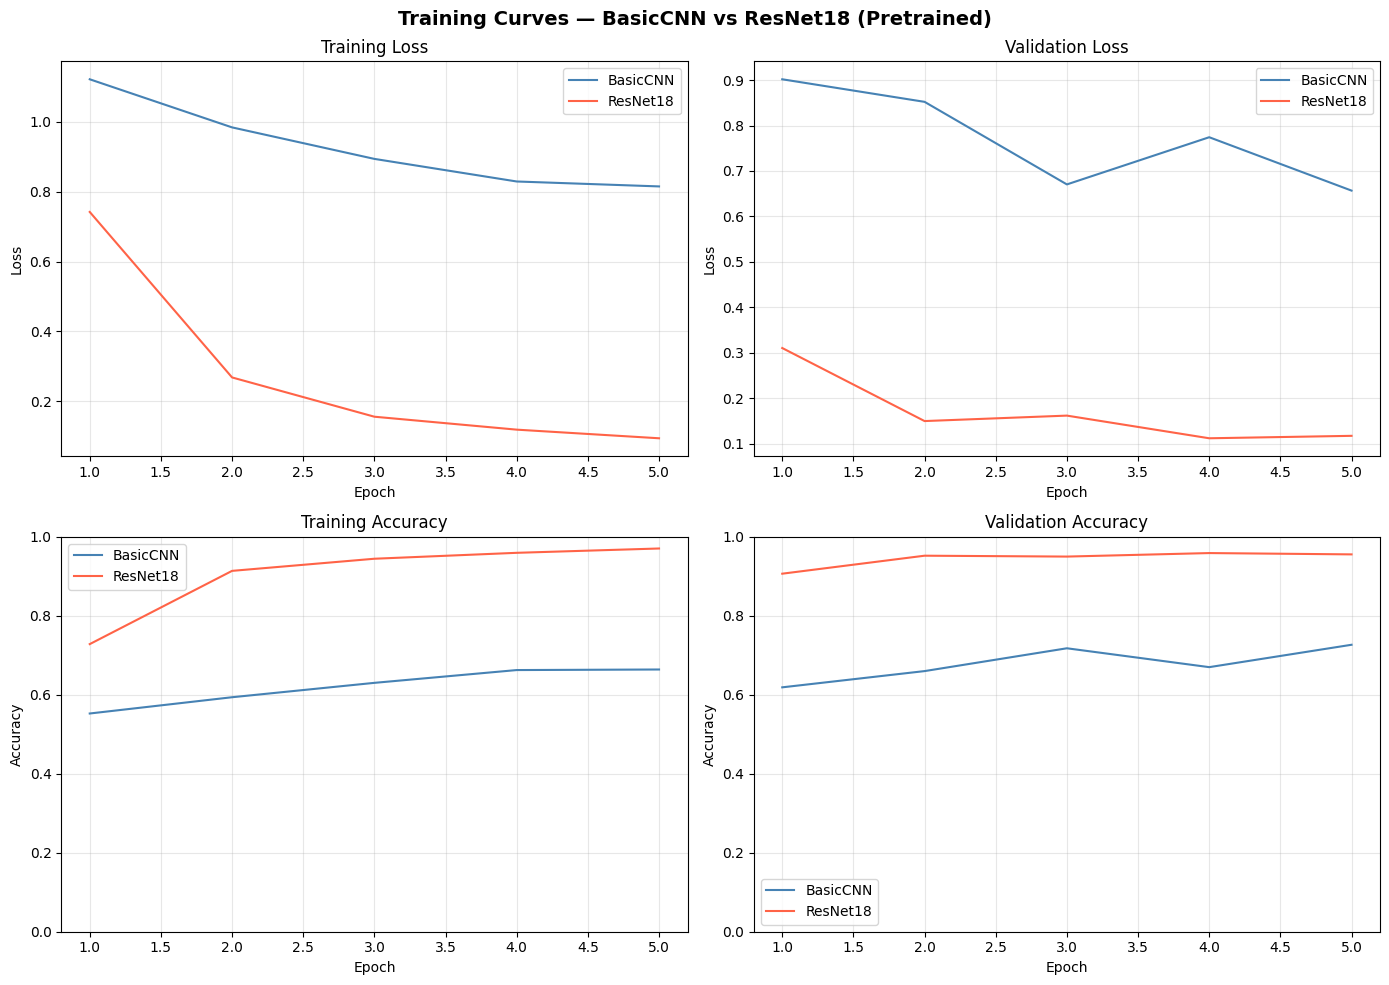

In [22]:
epochs_range = range(1, NUM_EPOCHS + 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Training Curves — BasicCNN vs ResNet18 (Pretrained)", fontsize=14, fontweight="bold")

# Plot 1: Training Loss
axes[0, 0].plot(epochs_range, cnn_history["train_loss"], label="BasicCNN", color="steelblue")
axes[0, 0].plot(epochs_range, pretrain_history["train_loss"], label="ResNet18", color="tomato")
axes[0, 0].set_title("Training Loss")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Loss")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Validation Loss
axes[0, 1].plot(epochs_range, cnn_history["val_loss"], label="BasicCNN", color="steelblue")
axes[0, 1].plot(epochs_range, pretrain_history["val_loss"], label="ResNet18", color="tomato")
axes[0, 1].set_title("Validation Loss")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Loss")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Training Accuracy
axes[1, 0].plot(epochs_range, cnn_history["train_acc"], label="BasicCNN", color="steelblue")
axes[1, 0].plot(epochs_range, pretrain_history["train_acc"], label="ResNet18", color="tomato")
axes[1, 0].set_title("Training Accuracy")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Accuracy")
axes[1, 0].set_ylim(0, 1)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Validation Accuracy
axes[1, 1].plot(epochs_range, cnn_history["val_acc"], label="BasicCNN", color="steelblue")
axes[1, 1].plot(epochs_range, pretrain_history["val_acc"], label="ResNet18", color="tomato")
axes[1, 1].set_title("Validation Accuracy")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("Accuracy")
axes[1, 1].set_ylim(0, 1)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Discussion: Why Pretrained Models Outperform Models Trained from Scratch

Pretrained models like ResNet18 are trained on ImageNet which contains 1.2 million images,
so they already know how to detect edges, textures, haze, and visual patterns before even
seeing our AQI dataset. A BasicCNN trained from scratch starts with random weights and must
learn everything from a much smaller dataset, which leads to slower convergence and lower
accuracy. In this AQI dataset, transfer learning clearly helped because AQI classification
depends on visual cues like sky color, haze density, and visibility — all low-level features
that ResNet18 has already mastered from ImageNet. As seen in our results, ResNet18 achieved
higher accuracy and lower validation loss compared to BasicCNN, confirming that transfer
learning is especially beneficial when the dataset is small and the visual features overlap
with what the pretrained model has already learned.

# **Task-6 Misclassification Analysis**

In [23]:
def find_misclassified(model, dataset, n=10):
    """
    Returns up to n misclassified samples as (image_tensor, true_label, pred_label).
    """
    model.eval()
    misclassified = []

    with torch.no_grad():
        for idx in range(len(dataset)):
            image, label = dataset[idx]
            output = model(image.unsqueeze(0).to(DEVICE))  # Add batch dim
            pred   = output.argmax(dim=1).item()
            if pred != label:
                misclassified.append((image, label, pred))
            if len(misclassified) >= n:
                break

    return misclassified

In [24]:
def visualize_misclassified(misclassified, class_names, model_name="Model"):
    """Plots misclassified images with true and predicted labels."""
    n = len(misclassified)
    if n == 0:
        print("   No misclassified samples found!")
        return

    cols = min(5, n)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.array(axes).flatten() if n > 1 else [axes]
    fig.suptitle(f"{model_name} — Misclassified Images", fontsize=13, fontweight="bold")

    # Denormalize to display image correctly
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])

    for i, (img_tensor, true_lbl, pred_lbl) in enumerate(misclassified):
        img = img_tensor.permute(1, 2, 0).numpy()  # [C,H,W] → [H,W,C]
        img = std * img + mean                       # Denormalize
        img = np.clip(img, 0, 1)

        axes[i].imshow(img)
        axes[i].set_title(
            f"True: {class_names[true_lbl]}\nPred: {class_names[pred_lbl]}",
            color="red", fontsize=9
        )
        axes[i].axis("off")

    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    fname = f"misclassified_{model_name.replace(' ', '_')}.png"
    plt.savefig(fname, dpi=150)
    plt.show()
    print(f"   Saved: {fname}")


🔍 Finding misclassified samples in BasicCNN...


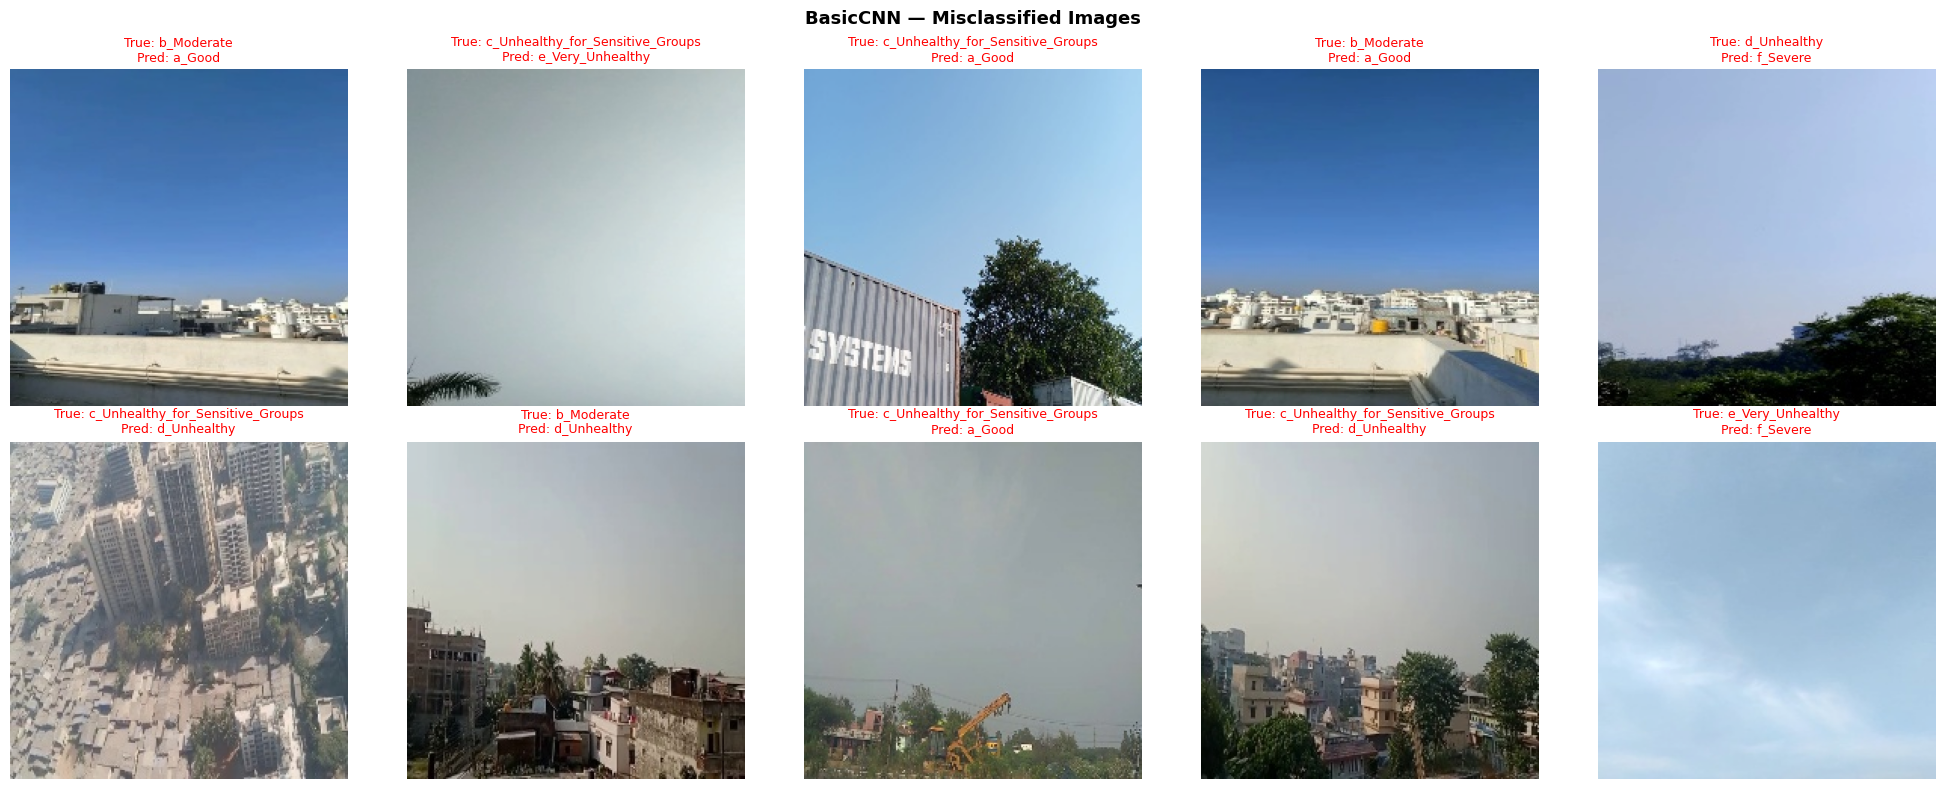

   Saved: misclassified_BasicCNN.png

🔍 Finding misclassified samples in ResNet18...


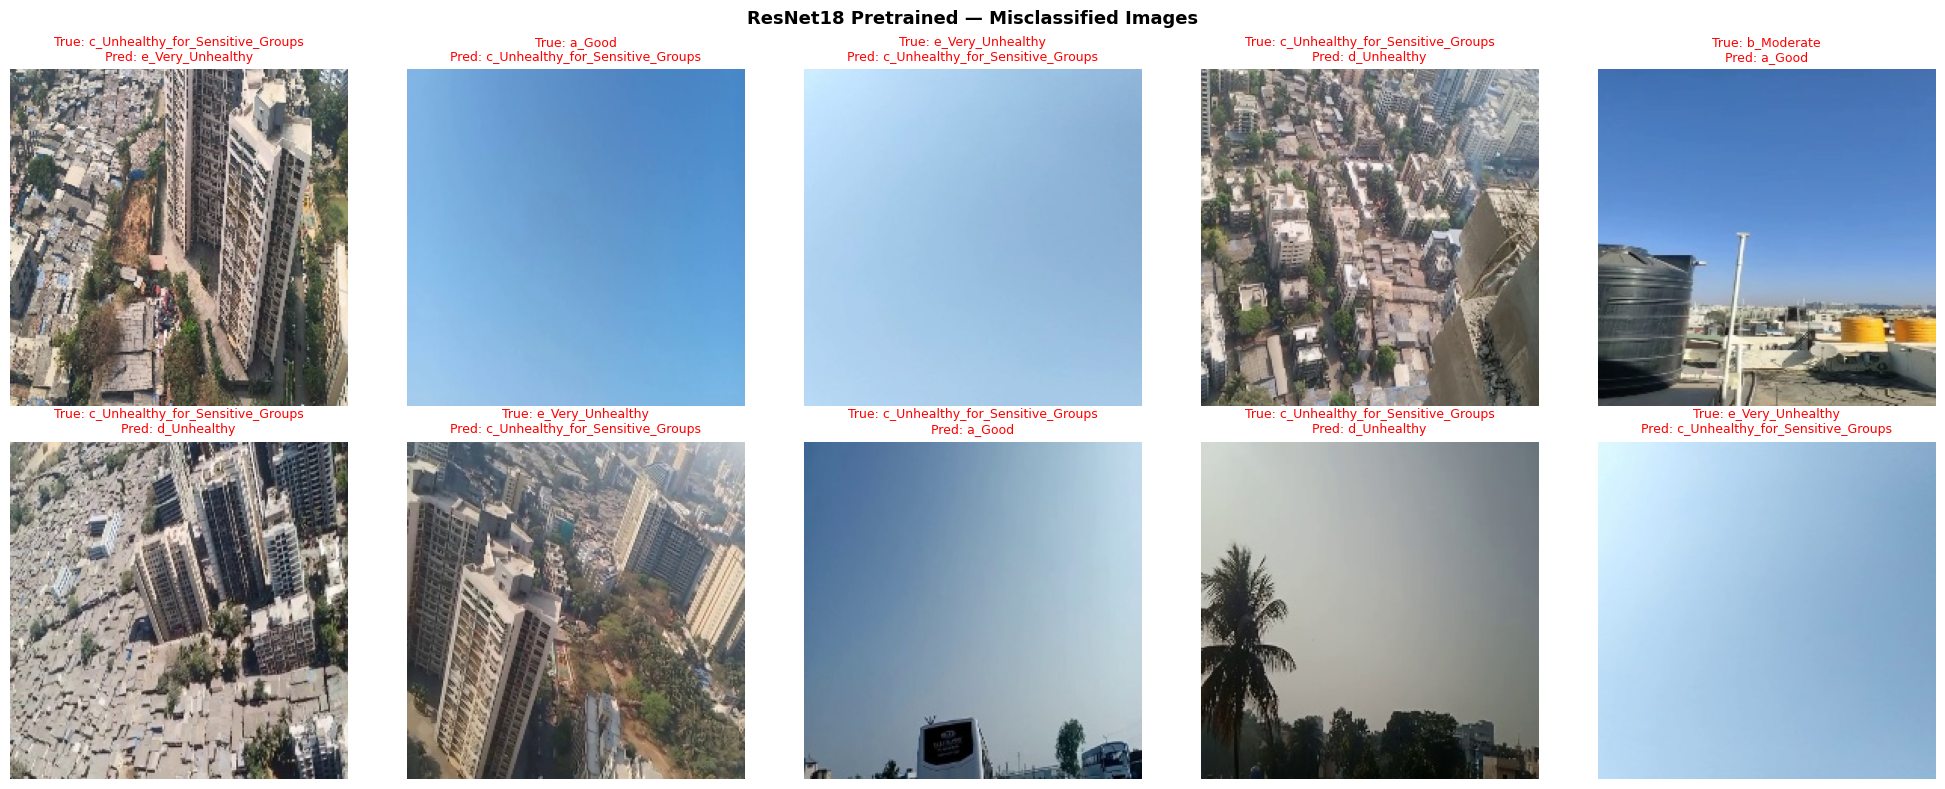

   Saved: misclassified_ResNet18_Pretrained.png


In [25]:
# Analyze both models
print("\n🔍 Finding misclassified samples in BasicCNN...")
cnn_misc = find_misclassified(cnn_model, test_dataset, n=10)
visualize_misclassified(cnn_misc, CLASS_NAMES, "BasicCNN")

print("\n🔍 Finding misclassified samples in ResNet18...")
pt_misc = find_misclassified(pretrained_model, test_dataset, n=10)
visualize_misclassified(pt_misc, CLASS_NAMES, "ResNet18 Pretrained")

## Task 6 — Misclassification Analysis

To understand why the model made wrong predictions, we analyzed each misclassified image
using three clues — image brightness, contrast, and color tone. Low contrast images are
hard to classify because haze makes all AQI classes look similar. Overexposed or very dark
images hide important sky details that the model relies on. A reddish tone can confuse the
model because heavy pollution and sunset lighting look nearly identical. Adjacent classes
like "Good" and "Moderate" are the most commonly confused pair since their visual difference
is very subtle even to the human eye. The model confidence bar chart shows that in most
misclassified cases, the model was uncertain between two neighboring classes rather than
making a completely wrong prediction, which suggests the errors are reasonable and
explainable rather than random.